# Main Code to carry out blocking statistics and diagnostics on model data (CESM+others) and observations

### Specific Code to:
#### 1. Setup the analysis to be done and data to be ingested
#### 2. Climatology plots
#### 3. Jet latitude index
#### 4. 1D Frequency plots
#### 5. 2d Frequency plots
#### 6. PDF of blocking strengths
#### 7. Composite of plots conditioned on blocking strength
#### 8. PDF of blocking/baroclinic events length

In [2]:
# IMPORT PACKAGES

import importlib
import blocking_utils as block_utils
import blocking_figs as block_figs

%load_ext autoreload
%autoreload 2

In [3]:
from dask.distributed import Client
from ncar_jobqueue import NCARCluster

In [4]:
cluster = NCARCluster(project='P93300642',interface='mgt', job_extra_directives=[])
cluster
cluster.scale(jobs=8)
client = Client(cluster)
client

/glade/work/rneale/python/miniconda3/envs/neale_blocking/lib/python3.11/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/work/rneale/python/miniconda3/envs/neale_blocking/lib/python3.11/site-packages/dask_jobqueue/core.py:285: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, 

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/8787/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.18.206.63:37953,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B



# TOP LEVEL OPTIONS


In [5]:
ens_names = ['ERA5','MERRA','CESM2']
ens_mem_num = [1,1,10]  # Ensemble members per ensemble set
ens_ystart = ['1979']*len(ens_names)
ens_yend     = ['2005']*len(ens_names)
block_season = 'DJF'
cam_var = 'Z500'
block_diag_hem = ['nhem']  
block_diag_set = ['1d']


# MAIN ROUTINES


In [6]:
importlib.reload(block_utils) # Required because I am constantly editing utility routines.

# Grab basic ens+run information and populate a dictionary)
block_meta = block_utils.ens_setup(ens_names,ens_mem_num,ens_ystart,ens_yend)

 
++ Large ensemble =  CESM2 :  10  out of  50  total (first/last) ++
b.e21.BHISTcmip6.f09_g17.LE2-1001.001
b.e21.BHISTcmip6.f09_g17.LE2-1181.010


,Ensemble Type,Ensemble Size,Start Year,End Year,Run Name,Run File
ERA5,obs,1,1979,2005,[ERA5],[/glade/work/rneale/data/ERA5/VAR_TBD.day.mean...
MERRA,obs,1,1979,2005,[MERRA],[/glade/work/rneale/data/MERRA/VAR_TBD.day.mea...
CESM2,model,10,1979,2005,"[b.e21.BHISTcmip6.f09_g17.LE2-1001.001, b.e21....",[/glade/campaign/cgd/cesm/CESM2-LE/atm/proc/ts...


# Grab daily datasets needed for each 'ensemble'

In [7]:
ensemble_ds = block_utils.dataset_get(block_meta,cam_var,block_season,block_diag_hem)

-> dataset_get -> Requested season     :  DJF
-> dataset_get ->  Opening ensemble  ERA5  -  1  ensemble(s)
-> dataset_get -> Requested year range :  1979 - 2005
-> dataset_get ->  Opening ensemble  MERRA  -  1  ensemble(s)
-> dataset_get -> Requested year range :  1979 - 2005
-> dataset_get ->  Opening ensemble  CESM2  -  10  ensemble(s)
-> dataset_get -> Requested year range :  1979 - 2005
-> dataset_get ->  Duration: 75.60541224479675



#  Calculate/Read/Write blocking frequency: 1D

In [8]:
ensemble_block_1d = block_utils.block_z500_freq(block_meta,ensemble_ds,block_season,block_diag = '1D', file_opts = 'w')

-> block_z500_freq ->   Calculating blocking statistics for  ERA5
-> block_file_read_write ->  Writing file for ensemble  ERA5  =  block_1D_ERA5_nens.1_1979-2005_DJF.nc
-> block_file_read_write ->  Done ...
-> block_z500_freq ->  Min/max blocking frequency for ensemble  ERA5  =  2.1748050882232253 , 24.169060320065654
-> block_z500_freq ->   Calculating blocking statistics for  MERRA
-> block_file_read_write ->  Writing file for ensemble  MERRA  =  block_1D_MERRA_nens.1_1979-2005_DJF.nc
-> block_file_read_write ->  Done ...
-> block_z500_freq ->  Min/max blocking frequency for ensemble  MERRA  =  1.4772260976610587 , 21.378744357816988
-> block_z500_freq ->   Calculating blocking statistics for  CESM2
-> block_file_read_write ->  Writing file for ensemble  CESM2  =  block_1D_CESM2_nens.10_1979-2005_DJF.nc
-> block_file_read_write ->  Done ...
-> block_z500_freq ->  Min/max blocking frequency for ensemble  CESM2  =  1.8106995884773662 , 18.68312757201646



# Calculate/Read/Write blocking frequency: 2D


In [9]:
ensemble_block_2d = block_utils.block_z500_freq(block_meta,ensemble_ds,block_season,block_diag = '2D', file_opts = 'w')

-> block_z500_freq ->   Calculating blocking statistics for  ERA5
-> block_file_read_write ->  Writing file for ensemble  ERA5  =  block_2D_ERA5_nens.1_1979-2005_DJF.nc
-> block_file_read_write ->  Done ...
-> block_z500_freq ->  Min/max blocking frequency for ensemble  ERA5  =  0.0 , 28.35453426343865
-> block_z500_freq ->   Calculating blocking statistics for  MERRA
-> block_file_read_write ->  Writing file for ensemble  MERRA  =  block_2D_MERRA_nens.1_1979-2005_DJF.nc
-> block_file_read_write ->  Done ...
-> block_z500_freq ->  Min/max blocking frequency for ensemble  MERRA  =  0.0 , 84.03775133360689
-> block_z500_freq ->   Calculating blocking statistics for  CESM2
-> block_file_read_write ->  Writing file for ensemble  CESM2  =  block_2D_CESM2_nens.10_1979-2005_DJF.nc
-> block_file_read_write ->  Done ...
-> block_z500_freq ->  Min/max blocking frequency for ensemble  CESM2  =  0.0 , 23.333333333333332



# Plot 1D blocking: Shade = 1,2 +/- std (or min to max range)


-> block_plot_1d ->  Plotting for ensemble ERA5
-> block_plot_1d ->  Plotting for ensemble MERRA
-> block_plot_1d ->  Plotting for ensemble CESM2
-> block_plot_1d ->  Duration: 2.0715436935424805



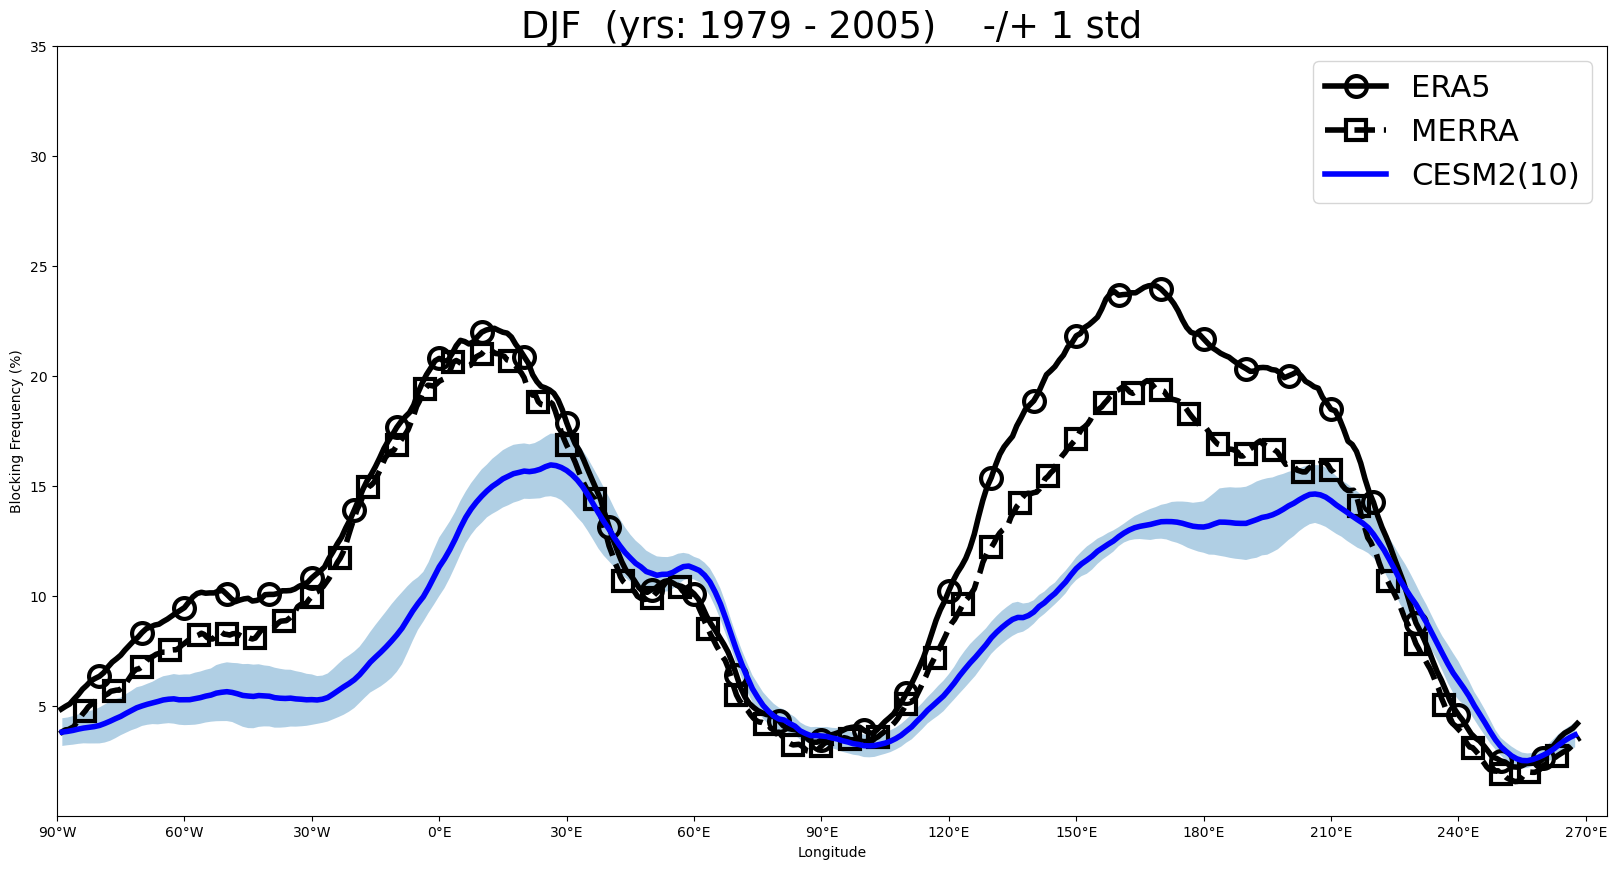

In [10]:
block_figs.block_plot_1d(block_meta,ensemble_block_1d,block_season,fig_out=True)


# Plot 2D blocking: Ensemble ave, 1 ensemble member, or all ensemble members 


-> block_plot_2d -> Plotting for ensemble ERA5
-> block_plot_2d -> Plotting for ensemble MERRA
-> block_plot_2d -> Plotting for ensemble CESM2


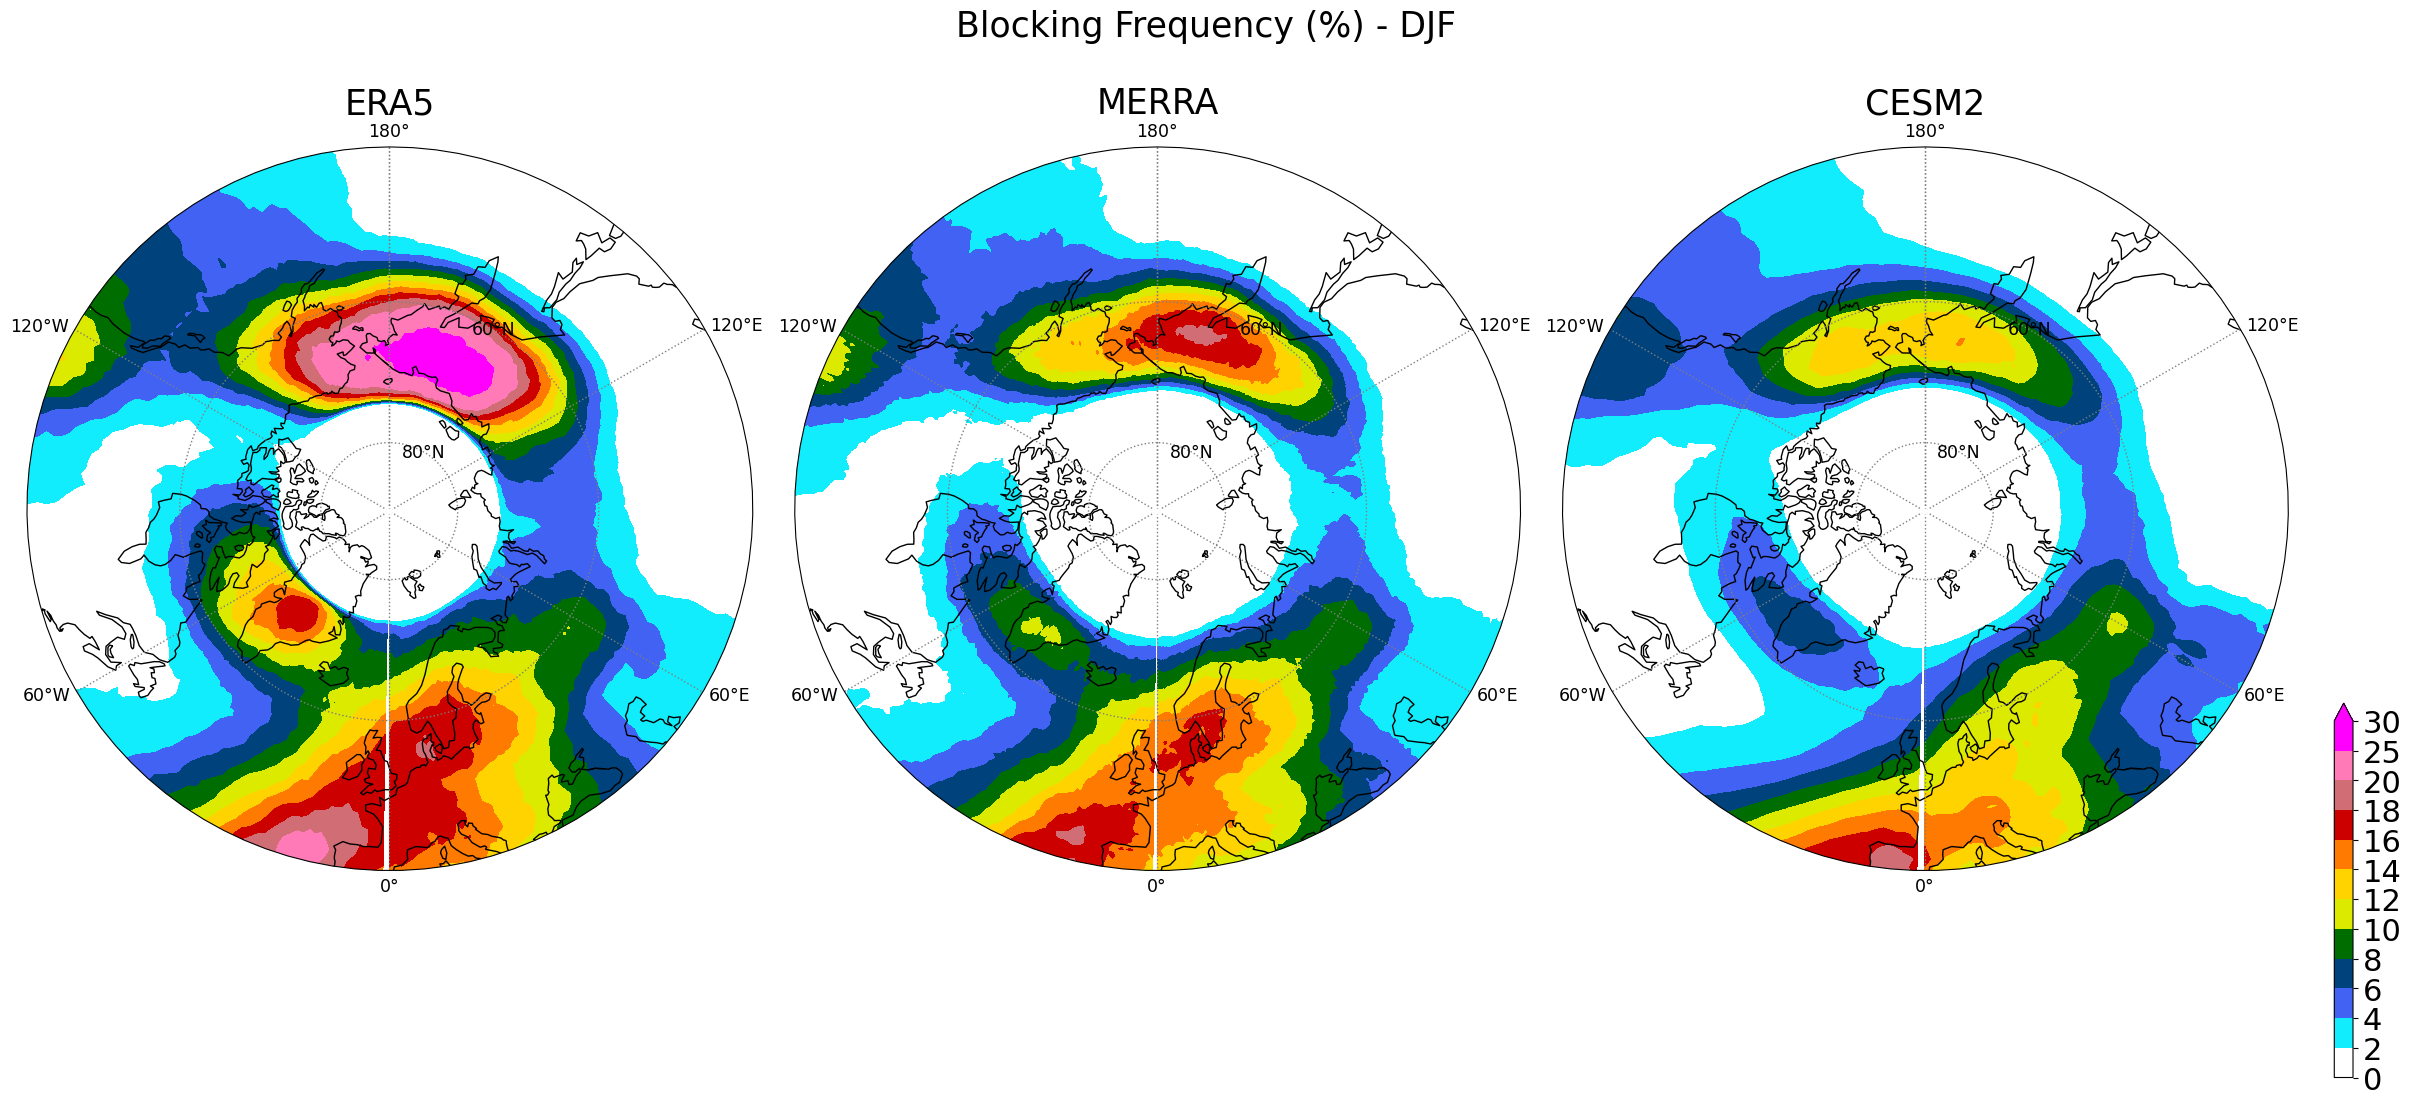

In [11]:
block_figs.block_plot_2d(block_meta,ensemble_block_2d,block_season,fig_out=True,ens_plot='av')


# Plot 1d regional blocking PDFs (European, Pacific and Greenland)


In [15]:
block_figs.block_plot_1d(block_meta,ensemble_block_1d,block_season,ens_plot='1',fig_out=True)

TypeError: block_plot_1d() got an unexpected keyword argument 'ens_plot'

In [ ]:
#bstats = atmos_block.stats
#bclimo = atmos_block.climo
#bjet_lat = atmos_block.get_lat
#bfreq_1d = atmos_block.bfreq_1d
#bfreq_2d = atmos_block.bfreq_2d
#bpdf_1d = atmos_block.bfreq_2d
#bcomp_lag = atmos_block.bfreq_lag
#bday_len = atmos_block.bday_len